# MCMC forecast for DESI DR2 BAO in flat $\Lambda$CDM

This notebook samples the **DESI DR2 BAO** likelihood with BlackJAX NUTS,
using the same BAO data products and background-theory model as
`fisher_DESI-DR2_BAO_LCDM.ipynb`.

The sampled cosmological parameters are $(\omega_b, \omega_{cdm}, h)$ with
neutrino mass fixed to $m_\nu = 0.06\,$eV.  A BBN prior on $\omega_b$ can be
enabled or disabled below.

## Imports

In [1]:
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

import numpy as np

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.linalg import inv

from ps_1loop_jax import background as bg

from jaxptpolypol.params import CosmoParams
from jaxptpolypol.bao import load_desi_dr2, make_bao_theory_fn
from jaxptpolypol.inference import fisher_matrix, gaussian_prior_fisher
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.chain_analysis import (
    make_bao_spec, packed_samples_to_dict, scalar_summary_packed, plot_trace,
)
from jaxptpolypol.sampler import (
    make_transform, make_gaussian_log_prior, make_log_posterior,
    run_nuts, samples_to_physical,
)

import os
N_THREADS = os.cpu_count()

os.environ["OMP_NUM_THREADS"] = str(N_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_THREADS)
os.environ["MKL_NUM_THREADS"] = str(N_THREADS)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(N_THREADS)
os.environ["NUMEXPR_NUM_THREADS"] = str(N_THREADS)

## Load DESI DR2 BAO data

In [2]:
bao_data_dir = "../../ext_data/bao_data/desi_bao_dr2"
bao_dr2 = load_desi_dr2("all", data_dir=bao_data_dir)

print(f"Number of data points: {len(bao_dr2.data_points)}")
print(f"Covariance shape:      {bao_dr2.cov.shape}")
print(f"rs_fid:                {bao_dr2.rs_fid}")
print()
print(f"{'z':>6s}  {'observable':>12s}  {'value':>12s}")
print("-" * 38)
for dp in bao_dr2.data_points:
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {dp.value:12.6f}")


Number of data points: 13
Covariance shape:      (13, 13)
rs_fid:                1.0

     z    observable         value
--------------------------------------
 0.295    DV_over_rs      7.941676
 0.510    DM_over_rs     13.587584
 0.510    DH_over_rs     21.862947
 0.706    DM_over_rs     17.350691
 0.706    DH_over_rs     19.455349
 0.934    DM_over_rs     21.575640
 0.934    DH_over_rs     17.641495
 1.321    DM_over_rs     27.600856
 1.321    DH_over_rs     14.176022
 1.484    DM_over_rs     30.511901
 1.484    DH_over_rs     12.817000
 2.330    DH_over_rs      8.631546
 2.330    DM_over_rs     38.988974


## Fiducial cosmology

In [3]:
# Fiducial cosmology (Planck 2018 best-fit)
cosmo_dict = {
    'ombh2': 0.02242,
    'omch2': 0.11933,
    'h':     0.6766,
}
cosmo = CosmoParams(cosmo_dict)
print(cosmo)

cosmo_keys = cosmo.param_keys
cosmo_sizes = cosmo.param_sizes
fiducial_params = cosmo.to_array()
n_varied = len(fiducial_params)

chain_spec = make_bao_spec(cosmo_keys=cosmo_keys, cosmo_sizes=cosmo_sizes)
param_names = chain_spec.varied_param_names()
param_labels = [chain_spec.varied_param_labels()[name] for name in param_names]

print(f"\nParameter keys:  {cosmo_keys}")
print(f"Parameter sizes: {cosmo_sizes}")
print(f"Packed array:    {fiducial_params}")


CosmoParams:
  ombh2: 0.02242
  omch2: 0.11933
  h: 0.6766

Parameter keys:  ('ombh2', 'omch2', 'h')
Parameter sizes: (1, 1, 1)
Packed array:    [0.02242 0.11933 0.6766 ]


## BAO theory and covariance

In [4]:
bao_fn = make_bao_theory_fn(
    bao_dr2,
    cosmo_keys=cosmo_keys,
    cosmo_sizes=cosmo_sizes,
    mnu_fixed=0.06,
)
jitted_bao_fn = jax.jit(bao_fn)

data = bao_dr2.data_vector
cov = bao_dr2.cov
cov_inv = inv(cov)

theory_fid = jitted_bao_fn(fiducial_params)

print(f"{'z':>6s}  {'observable':>12s}  {'data':>12s}  {'theory(fid)':>12s}  {'(th-d)/d [%]':>12s}")
print("-" * 72)
for i, dp in enumerate(bao_dr2.data_points):
    pct = 100 * (float(theory_fid[i]) - float(data[i])) / float(data[i])
    print(f"{dp.z:6.3f}  {dp.observable:>12s}  {float(data[i]):12.6f}  {float(theory_fid[i]):12.6f}  {pct:+10.3f} %")


     z    observable          data   theory(fid)  (th-d)/d [%]
------------------------------------------------------------------------
 0.295    DV_over_rs      7.941676      8.026287      +1.065 %
 0.510    DM_over_rs     13.587584     13.452675      -0.993 %
 0.510    DH_over_rs     21.862947     22.692781      +3.796 %
 0.706    DM_over_rs     17.350691     17.645969      +1.702 %
 0.706    DH_over_rs     19.455349     20.144123      +3.540 %
 0.934    DM_over_rs     21.575640     21.936343      +1.672 %
 0.934    DH_over_rs     17.641495     17.560093      -0.461 %
 1.321    DM_over_rs     27.600856     28.022939      +1.529 %
 1.321    DH_over_rs     14.176022     14.069755      -0.750 %
 1.484    DM_over_rs     30.511901     30.217927      -0.963 %
 1.484    DH_over_rs     12.817000     12.887747      +0.552 %
 2.330    DH_over_rs      8.631546      8.627777      -0.044 %
 2.330    DM_over_rs     38.988974     39.133932      +0.372 %


## Fisher matrix for whitening

In [5]:
jac = jax.jacfwd(jitted_bao_fn)(fiducial_params)
F_bao = fisher_matrix(cov, jac)

USE_BBN_PRIOR = True
USE_PAPER_BOX_PRIORS = True
MNU_FIXED = 0.06

PAPER_BAO_PRIORS = {
    "Omega_m": (0.01, 0.99),
    "H0": (20.0, 100.0),
    "ombh2": (0.005, 0.1),
}
PAPER_BAO_ONLY_PRIORS = {
    "Omega_m": (0.01, 0.99),
    "hrd": (10.0, 1000.0),
    "H0_fixed": 67.36,
    "ombh2_fixed": 0.02237,
}

# Schoneberg et al. (2024) BBN likelihood used by the DESI DR2 BAO paper.
# In the paper config this is a joint Gaussian in (omega_b h^2, N_eff), but
# the flat-LCDM runs fix N_eff = 3.044, so the notebook reduces it to the
# exact 1D Gaussian implied at fixed N_eff.
BBN_JOINT_MEAN = jnp.array([0.02196, 2.944], dtype=jnp.float64)
BBN_JOINT_COV = jnp.array([
    [4.0311226e-07, 7.30390042e-05],
    [7.30390042e-05, 4.52831584e-02],
], dtype=jnp.float64)
NNU_FIXED = 3.044
BBN_PREC = inv(BBN_JOINT_COV)
BBN_EFFECTIVE_MEAN = float(
    BBN_JOINT_MEAN[0]
    - BBN_PREC[0, 1] / BBN_PREC[0, 0] * (NNU_FIXED - BBN_JOINT_MEAN[1])
)
BBN_EFFECTIVE_SIGMA = float(jnp.sqrt(1.0 / BBN_PREC[0, 0]))

prior_entries = []
F_prior = jnp.zeros_like(F_bao)
if USE_BBN_PRIOR:
    prior_entries = [(0, BBN_EFFECTIVE_MEAN, BBN_EFFECTIVE_SIGMA)]
    F_prior = gaussian_prior_fisher(n_varied, {0: BBN_EFFECTIVE_SIGMA})

F_target = F_bao + F_prior
F_target_inv = inv(F_target)
fisher_sigma = jnp.sqrt(jnp.diag(F_target_inv))

print("BAO Fisher matrix:")
print(np.array(F_bao))
print()
print(f"Using BBN prior: {USE_BBN_PRIOR}")
if USE_BBN_PRIOR:
    print(
        "  Schoneberg 2024 effective prior at fixed N_eff = 3.044: "
        f"omega_b h^2 = {BBN_EFFECTIVE_MEAN:.6f} +/- {BBN_EFFECTIVE_SIGMA:.6f}"
    )
print(f"Using paper box priors in MCMC: {USE_PAPER_BOX_PRIORS}")
print(
    "  Omega_m in "
    f"[{PAPER_BAO_PRIORS['Omega_m'][0]:.2f}, {PAPER_BAO_PRIORS['Omega_m'][1]:.2f}], "
    "H0 in "
    f"[{PAPER_BAO_PRIORS['H0'][0]:.0f}, {PAPER_BAO_PRIORS['H0'][1]:.0f}] km/s/Mpc, "
    "omega_b h^2 in "
    f"[{PAPER_BAO_PRIORS['ombh2'][0]:.3f}, {PAPER_BAO_PRIORS['ombh2'][1]:.3f}]"
)
print(
    "  The Fisher comparison still uses only the local Gaussian BBN piece; "
    "the hard top-hat bounds are enforced in the MCMC log-prior."
)
print("Whitening scales from Fisher covariance:")
for name, sig in zip(cosmo_keys, fisher_sigma):
    print(f"  {name:>8s}: {float(sig):.6g}")

BAO Fisher matrix:
[[4614503.44095242  173251.32695733 -636763.91395722]
 [ 173251.32695733   62575.1999979   -40389.51170035]
 [-636763.91395722  -40389.51170035   92713.28497331]]

Using BBN prior: True
  Schoneberg 2024 effective prior at fixed N_eff = 3.044: omega_b h^2 = 0.022121 +/- 0.000534
Using paper box priors in MCMC: True
  Omega_m in [0.01, 0.99], H0 in [20, 100] km/s/Mpc, omega_b h^2 in [0.005, 0.100]
  The Fisher comparison still uses only the local Gaussian BBN piece; the hard top-hat bounds are enforced in the MCMC log-prior.
Whitening scales from Fisher covariance:
     ombh2: 0.000534139
     omch2: 0.0048746
         h: 0.00571897


## MCMC setup: whitening, priors, log-posterior

In [6]:
# Quick-turnaround mode for laptops; switch off for longer production chains.
LAPTOP_MODE = True

if LAPTOP_MODE:
    NUM_WARMUP = 400
    NUM_SAMPLES = 1200
    NUM_CHAINS = 4
    SCAN_CHUNK = 128
    PARALLEL = True
    MAX_TREE_DEPTH = (6, 8)  # (warmup_depth, sample_depth)
else:
    NUM_WARMUP = 1000
    NUM_SAMPLES = 4000
    NUM_CHAINS = 4
    SCAN_CHUNK = 256
    PARALLEL = True
    MAX_TREE_DEPTH = (8, 10)

def derived_Omega_m_with_mnu(params):
    ombh2, omch2, h = params
    return (ombh2 + omch2 + MNU_FIXED / 93.14) / h**2

def paper_box_log_prior(theta):
    ombh2, omch2, h = theta
    Omega_m = derived_Omega_m_with_mnu(theta)
    inside = (
        (PAPER_BAO_PRIORS['ombh2'][0] <= ombh2)
        & (ombh2 <= PAPER_BAO_PRIORS['ombh2'][1])
        & (PAPER_BAO_PRIORS['H0'][0] / 100.0 <= h)
        & (h <= PAPER_BAO_PRIORS['H0'][1] / 100.0)
        & (PAPER_BAO_PRIORS['Omega_m'][0] <= Omega_m)
        & (Omega_m <= PAPER_BAO_PRIORS['Omega_m'][1])
        & (omch2 > 0.0)
    )
    return jnp.where(inside, 0.0, -jnp.inf)

gaussian_log_prior = make_gaussian_log_prior(n_varied, prior_entries)

def log_prior_physical(theta):
    logp = gaussian_log_prior(theta)
    if USE_PAPER_BOX_PRIORS:
        logp = logp + paper_box_log_prior(theta)
    return logp

to_whitened, to_physical = make_transform(center=fiducial_params, scale=fisher_sigma)
log_post = make_log_posterior(
    theory_fn=jitted_bao_fn,
    data=data,
    cov_inv=cov_inv,
    log_prior_fn=log_prior_physical,
    to_physical=to_physical,
)

x0 = jnp.zeros(n_varied)
lp0 = log_post(x0)

print(f"Mode: {'LAPTOP' if LAPTOP_MODE else 'SERVER'}")
print(f"  warmup: {NUM_WARMUP}, samples: {NUM_SAMPLES}, chains: {NUM_CHAINS}")
print(f"  scan_chunk: {SCAN_CHUNK}, parallel_chains: {PARALLEL}")
print(f"  max_tree_depth: {MAX_TREE_DEPTH}")
print(f"log-posterior at fiducial point: {float(lp0):.6f}")

Mode: LAPTOP
  warmup: 400, samples: 1200, chains: 4
  scan_chunk: 128, parallel_chains: True
log-posterior at fiducial point: -11.880598


## NUTS sampling

`MAX_TREE_DEPTH` can be either a single integer or a pair
`(warmup_depth, sample_depth)`. Use the pair form if you want to keep warmup
trajectories shorter than production trajectories.

In [7]:
%%time
rng_key = jax.random.key(42)

# Whitening handles the marginal scales, so a diagonal identity metric is the
# natural fixed choice in whitened coordinates.
ADAPT_MASS_MATRIX = False
MASS_MATRIX_TYPE = "diagonal"
INITIAL_INVERSE_MASS_MATRIX = jnp.ones(n_varied)

samples_w, diagnostics = run_nuts(
    rng_key,
    log_post,
    initial_position=x0,
    num_warmup=NUM_WARMUP,
    num_samples=NUM_SAMPLES,
    num_chains=NUM_CHAINS,
    adapt_mass_matrix=ADAPT_MASS_MATRIX,
    mass_matrix_type=MASS_MATRIX_TYPE,
    initial_inverse_mass_matrix=INITIAL_INVERSE_MASS_MATRIX,
    max_tree_depth=MAX_TREE_DEPTH,
    scan_chunk_size=SCAN_CHUNK,
    parallel_chains=PARALLEL,
    progress_fn=lambda c, n: print(f"  warmup chain {c}/{n} done"),
)

print(f"\nSamples shape: {samples_w.shape}  (chains, samples, params)")

  warmup chain 1/4 done


  warmup chain 2/4 done


  warmup chain 3/4 done


  warmup chain 4/4 done



Samples shape: (4, 1200, 3)  (chains, samples, params)
CPU times: user 10.8 s, sys: 483 ms, total: 11.3 s
Wall time: 6.23 s


## Diagnostics

Per-chain diagnostics:
  Chain 1:  accept = 0.943   steps = 8.2   divergent = 0
  Chain 2:  accept = 0.928   steps = 7.1   divergent = 0
  Chain 3:  accept = 0.948   steps = 8.4   divergent = 0
  Chain 4:  accept = 0.927   steps = 7.6   divergent = 0


Text(0.5, 0.98, 'Trace plots (whitened space)')

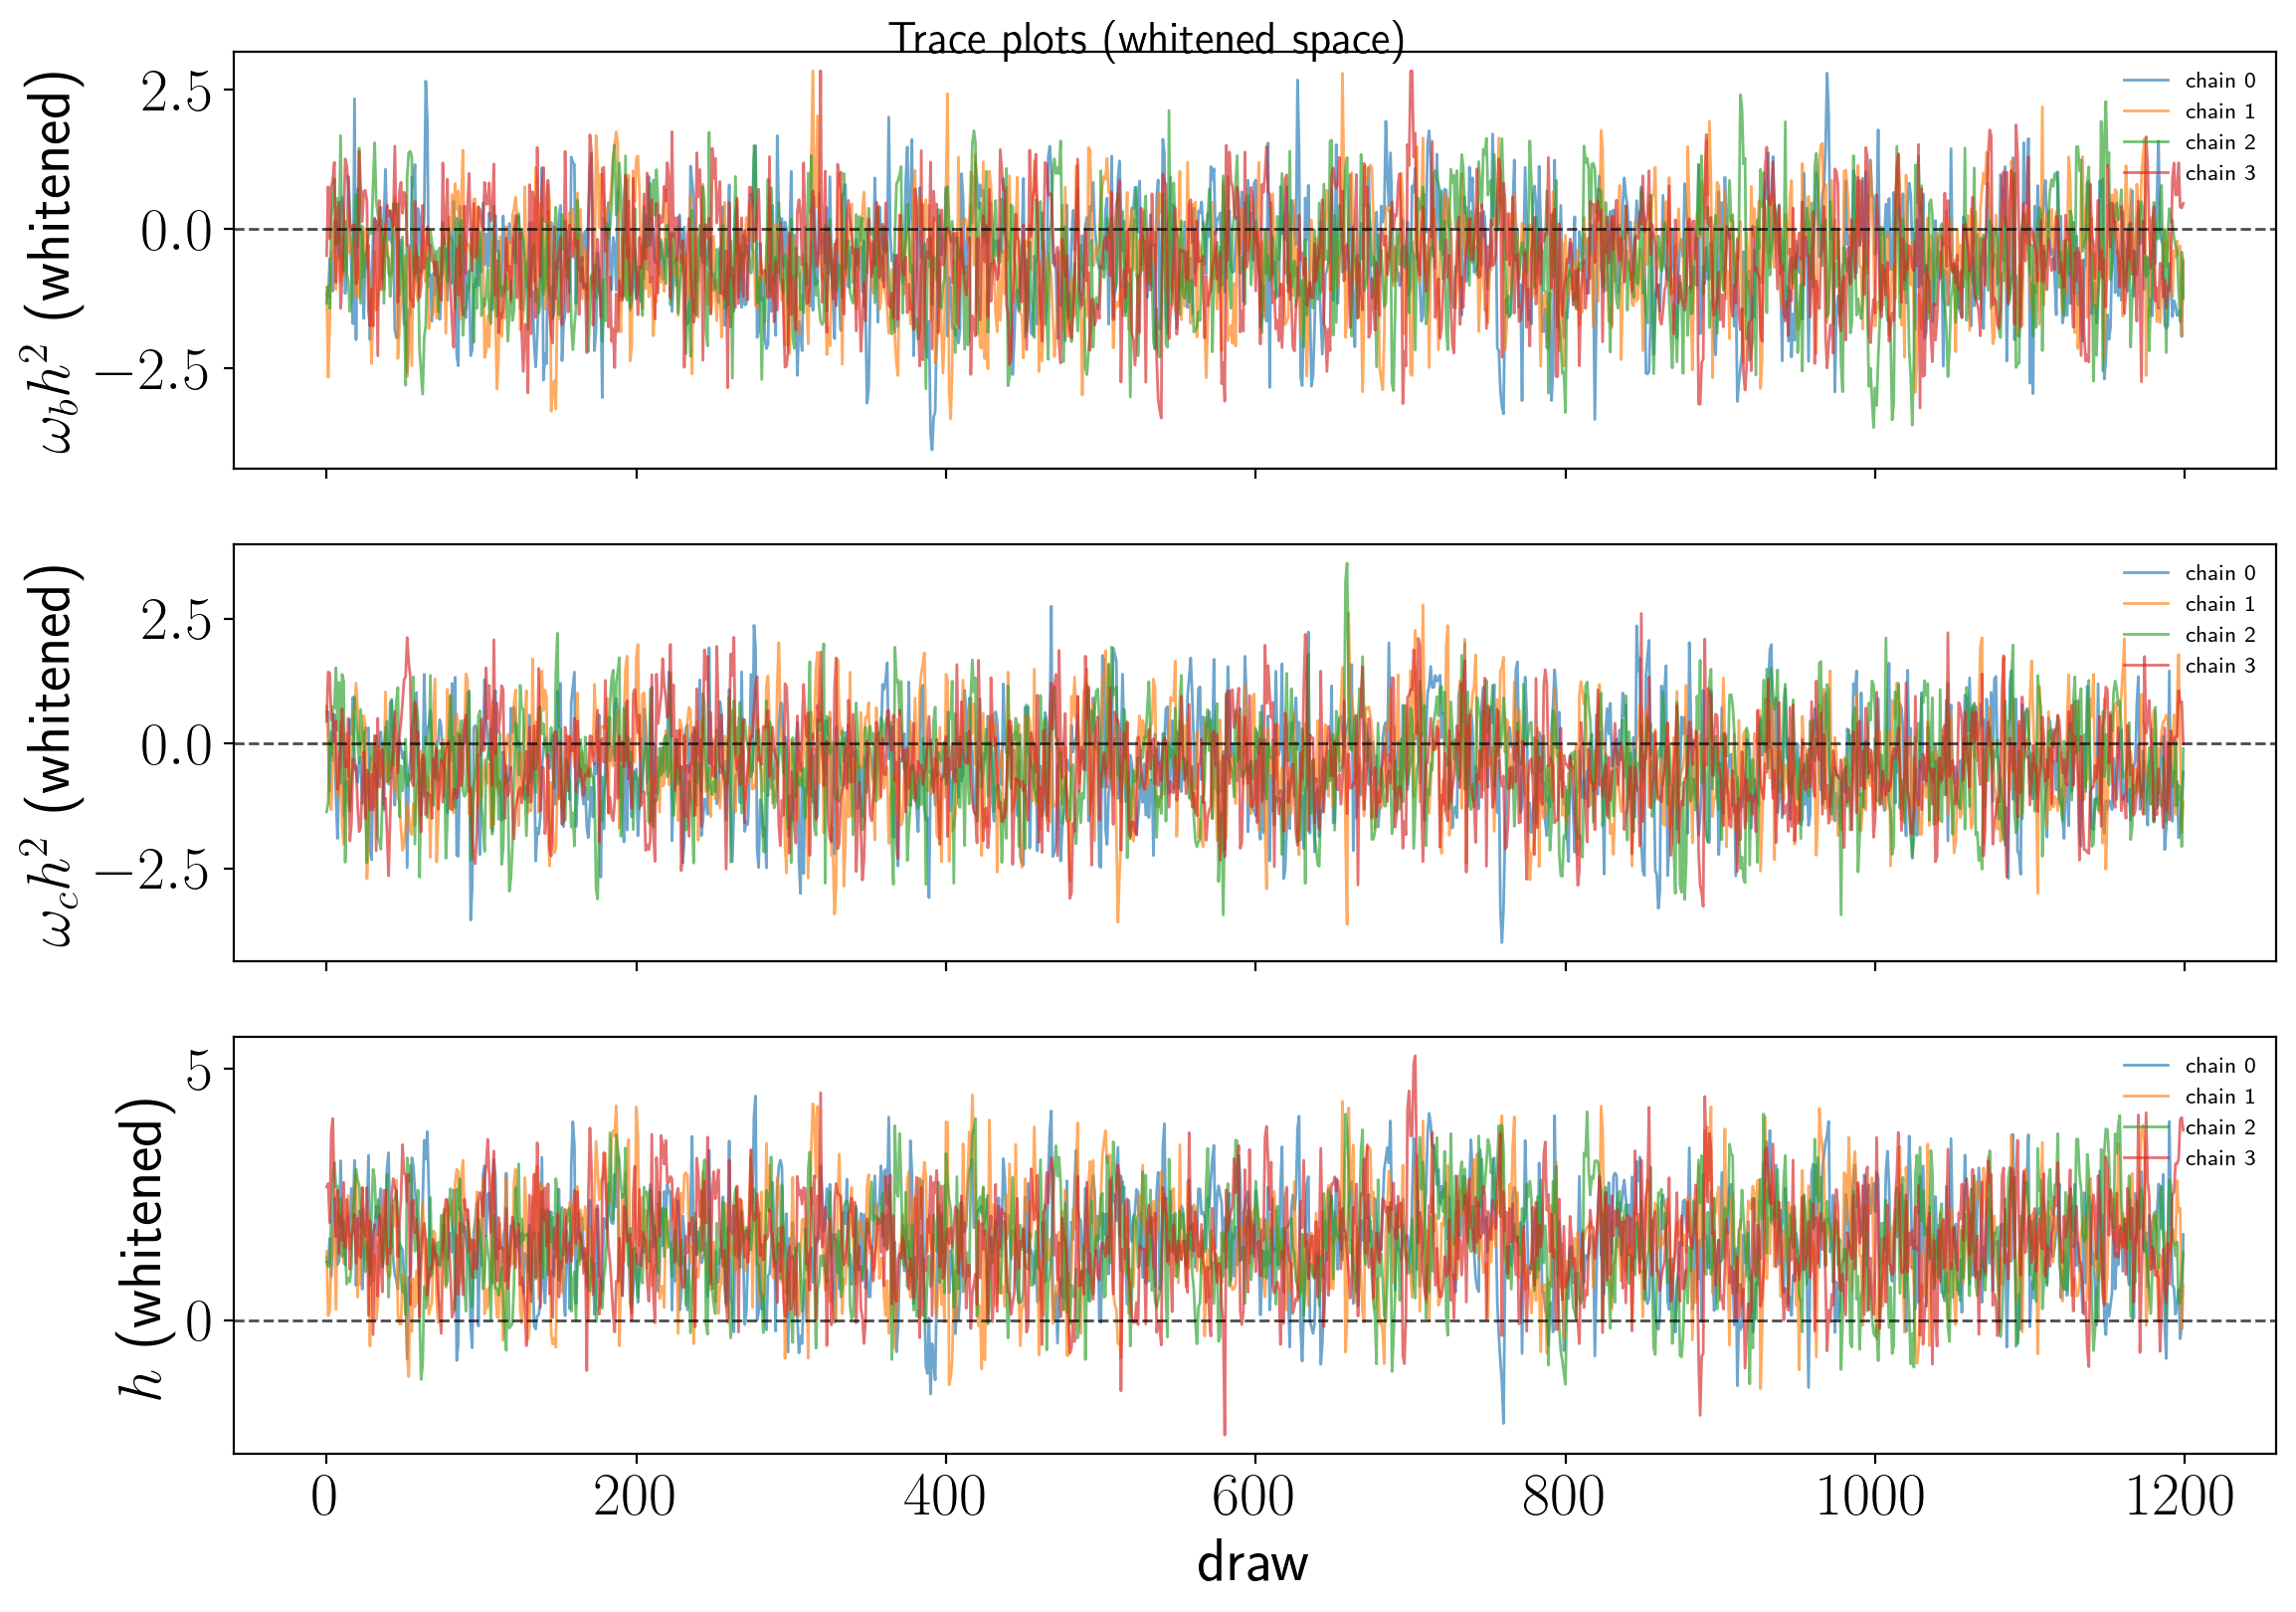

In [8]:
accept = diagnostics["acceptance_rate"]
n_steps = diagnostics["num_integration_steps"]
divergent = diagnostics["is_divergent"]

print("Per-chain diagnostics:")
for c in range(samples_w.shape[0]):
    print(
        f"  Chain {c+1}:  accept = {float(accept[c].mean()):.3f}"
        f"   steps = {float(n_steps[c].mean()):.1f}"
        f"   divergent = {int(divergent[c].sum())}"
    )

named_samples_w = packed_samples_to_dict(samples_w, chain_spec)
trace_labels = {
    name: f"{chain_spec.varied_param_labels()[name]} (whitened)"
    for name in param_names
}
fig, axes = plot_trace(
    named_samples_w,
    var_names=param_names,
    truths={name: 0.0 for name in param_names},
    var_labels=trace_labels,
    chain_axis=0,
    draw_axis=1,
    figsize=(12, 2.8 * len(param_names)),
    alpha=0.65,
)
fig.suptitle('Trace plots (whitened space)', fontsize=16)


## Posterior in physical space

In [9]:
samples_phys = samples_to_physical(samples_w, to_physical)
named_samples_phys = packed_samples_to_dict(samples_phys, chain_spec)
summary_phys = scalar_summary_packed(samples_phys, chain_spec)
flat_samples_w = samples_w.reshape(-1, n_varied)
flat_samples = samples_phys.reshape(-1, n_varied)
flat_log_post = jax.vmap(log_post)(flat_samples_w)
flat_divergent = np.asarray(diagnostics["is_divergent"]).reshape(-1).astype(bool)

valid_mask = ~flat_divergent
if np.any(valid_mask):
    map_scores = np.where(valid_mask, np.asarray(flat_log_post), -np.inf)
else:
    map_scores = np.asarray(flat_log_post)

map_idx = int(np.argmax(map_scores))
fisher_fiducial_params = jnp.asarray(np.asarray(flat_samples)[map_idx])
map_log_post = float(np.asarray(flat_log_post)[map_idx])
jac_map = jax.jacfwd(jitted_bao_fn)(fisher_fiducial_params)
F_bao_map = fisher_matrix(cov, jac_map)
F_target_map = F_bao_map + F_prior
F_target_map_inv = inv(F_target_map)
sample_cov = jnp.asarray(np.cov(np.asarray(flat_samples), rowvar=False))

print("Posterior summary:")
for i, name in enumerate(param_names):
    stats = summary_phys[name]
    start = float(fiducial_params[i])
    map_val = float(fisher_fiducial_params[i])
    mu = stats['mean']
    sig = float(jnp.sqrt(sample_cov[i, i]))
    print(
        f"  {name:>8s}: start = {start:.6f}   MAP = {map_val:.6f}"
        f"   mean = {mu:.6f}   std = {sig:.6f}"
    )

print()
print("Fisher comparison point (taken from the MCMC MAP sample):")
for name, val in zip(param_names, fisher_fiducial_params):
    print(f"  {name:>8s}: {float(val):.6f}")
print(f"  log-posterior at MAP sample: {map_log_post:.6f}")


Posterior summary:
     ombh2: start = 0.022420   MAP = 0.022115   mean = 0.022133   std = 0.000521
     omch2: start = 0.119330   MAP = 0.117014   mean = 0.117200   std = 0.004743
         h: start = 0.676600   MAP = 0.685154   mean = 0.685503   std = 0.005754

Fisher comparison point (taken from the MCMC MAP sample):
     ombh2: 0.022115
     omch2: 0.117014
         h: 0.685154
  log-posterior at MAP sample: -5.138290


## Corner plot: MCMC vs Fisher

Text(0.5, 0.98, 'MCMC (blue) vs Fisher@MAP (red dashed) -- DESI DR2 BAO')

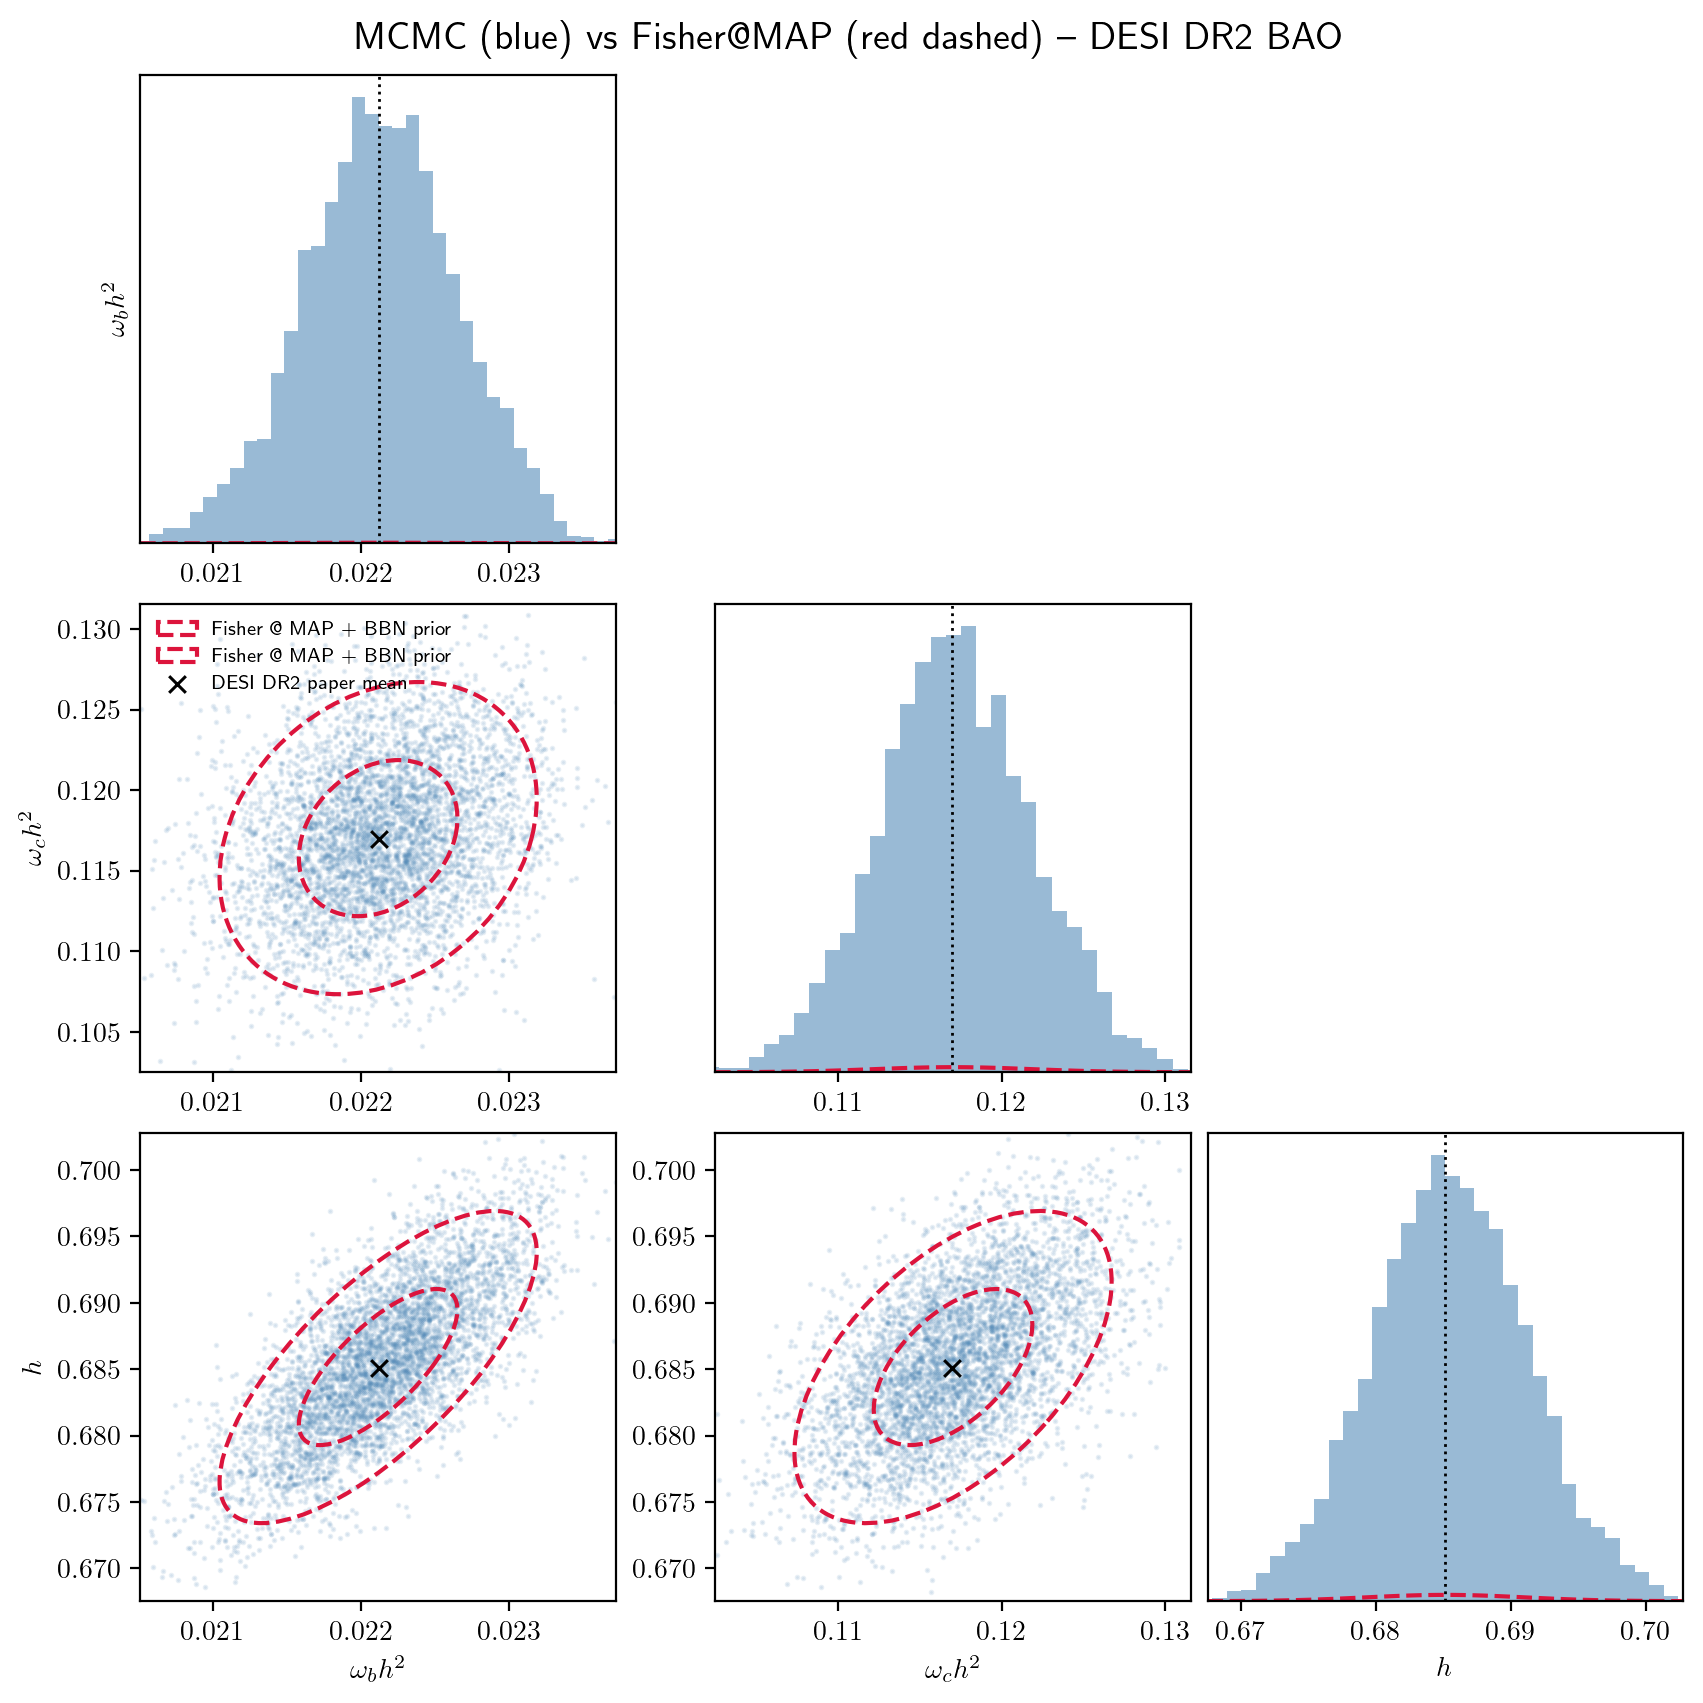

In [10]:
n_plot = len(param_names)
fid_vals = np.array(fisher_fiducial_params)

# DESI DR2 flat-LCDM posterior means from Table V of PRD 112, 083515 (2025).
# For BAO-only, the paper quotes (Omega_m, h * r_d) rather than (omega_b, omega_cdm, h),
# so we keep omega_b fixed to the Fisher comparison fiducial when mapping that point into this basis.
def desi_dr2_paper_point(use_bbn_prior):
    if use_bbn_prior:
        omega_b = prior_entries[0][1]
        Omega_m = 0.2977
        h = 0.6851
        omega_cdm = Omega_m * h**2 - omega_b - MNU_FIXED / 93.14
    else:
        omega_b = float(fisher_fiducial_params[0])
        Omega_m = 0.2975
        hrd = 101.54

        def residual(h):
            omega_cdm = Omega_m * h**2 - omega_b - MNU_FIXED / 93.14
            return float(h * bg.sound_horizon_drag(omega_b, omega_cdm, h, mnu=MNU_FIXED) - hrd)

        lo, hi = 0.55, 0.80
        flo, fhi = residual(lo), residual(hi)
        if flo * fhi > 0:
            raise RuntimeError('Could not bracket the DESI DR2 BAO-only h solution.')
        for _ in range(80):
            mid = 0.5 * (lo + hi)
            fmid = residual(mid)
            if flo * fmid <= 0:
                hi, fhi = mid, fmid
            else:
                lo, flo = mid, fmid
        h = 0.5 * (lo + hi)
        omega_cdm = Omega_m * h**2 - omega_b - MNU_FIXED / 93.14

    return np.array([omega_b, omega_cdm, h], dtype=float)

paper_vals = desi_dr2_paper_point(USE_BBN_PRIOR)

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(n_plot * 2.8, n_plot * 2.8), constrained_layout=True)

for i in range(n_plot):
    for j in range(n_plot):
        ax = plt.subplot(n_plot, n_plot, i * n_plot + j + 1)
        if j < i:
            ax.scatter(
                flat_samples[:, j], flat_samples[:, i],
                s=1.0, alpha=0.12, color='steelblue', rasterized=True,
            )
            plot_contours(
                F_target_map, fid_vals, [j, i], ax=ax,
                edgecolor='crimson', facecolor='none', ls='--', lw=1.5,
                label='Fisher @ MAP + BBN prior' if (i == 1 and j == 0) else None,
            )
            ax.scatter(
                paper_vals[j], paper_vals[i],
                marker='x', s=36, color='black', linewidths=1.1,
                label='DESI DR2 paper mean' if (i == 1 and j == 0) else None,
                zorder=6,
            )
            if i == 1 and j == 0:
                ax.legend(fontsize=7, frameon=False, loc='upper left')
        elif j == i:
            ax.hist(flat_samples[:, i], bins=40, density=True,
                    color='steelblue', alpha=0.55, edgecolor='none')
            plot_Gaussian(F_target_map, fid_vals, i, ax=ax,
                          color='crimson', ls='--', lw=1.5)
            ax.axvline(paper_vals[i], color='black', ls=':', lw=1.0)
            ax.set_yticks([])
        else:
            ax.axis('off')

        if i == n_plot - 1 and j <= i:
            ax.set_xlabel(param_labels[j])
        if j == 0 and j < i:
            ax.set_ylabel(param_labels[i])
        elif j == 0 and i == j:
            ax.set_ylabel(param_labels[i])

fig.suptitle(r'MCMC (blue) vs Fisher@MAP (red dashed) -- DESI DR2 BAO', fontsize=14)

## Derived parameters and published-constraint comparison

In [11]:
# DESI DR2 flat-LCDM posterior means from Table V of PRD 112, 083515 (2025).
def desi_dr2_paper_point(use_bbn_prior):
    if use_bbn_prior:
        omega_b = prior_entries[0][1]
        Omega_m = 0.2977
        h = 0.6851
        omega_cdm = Omega_m * h**2 - omega_b - MNU_FIXED / 93.14
        paper_note = (
            'Mapped into (omega_b, omega_cdm, h) using the Schoneberg 2024 BBN '                'prior reduced to fixed N_eff = 3.044, which is the flat-LCDM setup '                'used by the DESI DR2 BAO paper.'
        )
    else:
        omega_b = float(fisher_fiducial_params[0])
        Omega_m = 0.2975
        hrd = 101.54

        def residual(h):
            omega_cdm = Omega_m * h**2 - omega_b - MNU_FIXED / 93.14
            return float(h * bg.sound_horizon_drag(omega_b, omega_cdm, h, mnu=MNU_FIXED) - hrd)

        lo, hi = 0.55, 0.80
        flo, fhi = residual(lo), residual(hi)
        if flo * fhi > 0:
            raise RuntimeError('Could not bracket the DESI DR2 BAO-only h solution.')
        for _ in range(80):
            mid = 0.5 * (lo + hi)
            fmid = residual(mid)
            if flo * fmid <= 0:
                hi, fhi = mid, fmid
            else:
                lo, flo = mid, fmid
        h = 0.5 * (lo + hi)
        omega_cdm = Omega_m * h**2 - omega_b - MNU_FIXED / 93.14
        paper_note = (
            'The BAO-only paper summary quotes (Omega_m, h * r_d) rather than '                '(omega_b, omega_cdm, h), so the corner-plot marker holds omega_b at '                'the Fisher comparison fiducial (the MCMC MAP value) and solves for h '                'from the published h * r_d.'
        )

    return np.array([omega_b, omega_cdm, h], dtype=float), paper_note

def derived_Omega_m(params):
    ombh2, omch2, h = params
    return (ombh2 + omch2 + MNU_FIXED / 93.14) / h**2

def derived_h_rd(params):
    ombh2, omch2, h = params
    rd = bg.sound_horizon_drag(ombh2, omch2, h, mnu=MNU_FIXED)
    return h * rd

def derived_H0(params):
    return 100.0 * params[2]

jac_Om = jax.jacfwd(derived_Omega_m)(fisher_fiducial_params)
jac_hrd = jax.jacfwd(derived_h_rd)(fisher_fiducial_params)
jac_H0 = jax.jacfwd(derived_H0)(fisher_fiducial_params)

def fisher_sigma_derived(jac_derived):
    return float(jnp.sqrt(jac_derived @ F_target_map_inv @ jac_derived))

paper_vals, paper_note = desi_dr2_paper_point(USE_BBN_PRIOR)

Omega_m_samples = jax.vmap(derived_Omega_m)(flat_samples)
hrd_samples = jax.vmap(derived_h_rd)(flat_samples)
H0_samples = jax.vmap(derived_H0)(flat_samples)

print(f"Using BBN prior: {USE_BBN_PRIOR}")
print(f"Using paper box priors in MCMC: {USE_PAPER_BOX_PRIORS}")
print()
print(f"{'Parameter':>12s}  {'MAP fid':>12s}  {'Fisher':>12s}  {'MCMC':>12s}")
print("-" * 56)
print(f"{'Omega_m':>12s}  {float(derived_Omega_m(fisher_fiducial_params)):12.5f}  {fisher_sigma_derived(jac_Om):12.5f}  {float(jnp.std(Omega_m_samples)):12.5f}")
print(f"{'h*rd [Mpc]':>12s}  {float(derived_h_rd(fisher_fiducial_params)):12.3f}  {fisher_sigma_derived(jac_hrd):12.3f}  {float(jnp.std(hrd_samples)):12.3f}")
print(f"{'H0':>12s}  {float(derived_H0(fisher_fiducial_params)):12.3f}  {fisher_sigma_derived(jac_H0):12.3f}  {float(jnp.std(H0_samples)):12.3f}")

if USE_BBN_PRIOR:
    print()
    print("Published DESI DR2 + BBN reference values (flat LCDM):")
    print("  Omega_m        = 0.2977")
    print("  H0             = 68.51 km/s/Mpc")
    print("  sigma(Omega_m) = 0.0086")
    print("  sigma(H0)      = 0.58 km/s/Mpc")
else:
    print()
    print("Published DESI DR2 BAO-only reference values (flat LCDM):")
    print("  Omega_m        = 0.2975")
    print("  h*rd           = 101.54 Mpc")
    print("  sigma(Omega_m) = 0.0086")
    print("  sigma(h*rd)    = 0.73 Mpc")

print()
print("Mapped DESI DR2 paper mean into the notebook parameter basis:")
print(f"  omega_b        = {paper_vals[0]:.5f}")
print(f"  omega_cdm      = {paper_vals[1]:.5f}")
print(f"  h              = {paper_vals[2]:.5f}")
print(f"  Omega_m        = {float(derived_Omega_m(paper_vals)):.5f}")
if USE_BBN_PRIOR:
    print(f"  H0             = {float(derived_H0(paper_vals)):.2f} km/s/Mpc")
else:
    print(f"  h*rd           = {float(derived_h_rd(paper_vals)):.2f} Mpc")
print()
print("Assumption for plotting the black paper marker:")
print(f"  {paper_note}")
print("Why it is offset from the Fisher fiducial:")
print("  The Fisher forecast is now linearized around the MCMC MAP point,")
print("  while the black marker shows the DESI DR2 posterior mean reported by the paper.")
print("  The original Planck 2018 point is still used only to initialize the whitening transform for NUTS.")

Using BBN prior: True
Using paper box priors in MCMC: True

   Parameter       MAP fid        Fisher          MCMC
--------------------------------------------------------
     Omega_m       0.29775       0.00858       0.00843
  h*rd [Mpc]       101.499         0.733         0.726
          H0        68.515         0.587         0.575

Published DESI DR2 + BBN reference values (flat LCDM):
  Omega_m        = 0.2977
  H0             = 68.51 km/s/Mpc
  sigma(Omega_m) = 0.0086
  sigma(H0)      = 0.58 km/s/Mpc

Mapped DESI DR2 paper mean into the notebook parameter basis:
  omega_b        = 0.02212
  omega_cdm      = 0.11696
  h              = 0.68510
  Omega_m        = 0.29770
  H0             = 68.51 km/s/Mpc

Assumption for plotting the black paper marker:
  Mapped into (omega_b, omega_cdm, h) using the Schoneberg 2024 BBN prior reduced to fixed N_eff = 3.044, which is the flat-LCDM setup used by the DESI DR2 BAO paper.
Why it is offset from the Fisher fiducial:
  The Fisher forecast is

## $1\sigma$ comparison: MCMC vs Fisher

In [12]:
sigma_fisher = jnp.sqrt(jnp.diag(F_target_map_inv))

print(f"{'Parameter':>12s}  {'MAP fid':>10s}  {'Fisher':>10s}  {'MCMC':>10s}  {'Ratio':>8s}")
print("-" * 60)
for i, name in enumerate(param_names):
    fid = float(fisher_fiducial_params[i])
    sf = float(sigma_fisher[i])
    sm = float(jnp.sqrt(sample_cov[i, i]))
    print(f"{name:>12s}  {fid:10.5g}  {sf:10.4g}  {sm:10.4g}  {sm / sf:8.3f}")


   Parameter     MAP fid      Fisher        MCMC     Ratio
------------------------------------------------------------
       ombh2    0.022115   0.0005341   0.0005206     0.975
       omch2     0.11701    0.004847    0.004743     0.979
           h     0.68515    0.005874    0.005754     0.979


## Individual galaxy-sample posteriors in the DESI DR2 BAO-only plane

The DESI DR2 BAO paper samples the BAO-only flat-$\Lambda$CDM cases in
$(\Omega_m, h\,r_d)$ with flat top-hat priors,
$\Omega_m \in [0.01, 0.99]$ and $h\,r_d \in [10, 1000]$ Mpc, while keeping
$H_0 = 67.36\ \mathrm{km/s/Mpc}$ and $\omega_b = 0.02237$ fixed.

For the individual galaxy tracers below, the notebook follows that same
parameterization directly. That is why the tracer-by-tracer posteriors are
shown in the paper's BAO-only plane rather than in
$(\omega_b, \omega_{\mathrm{cdm}}, h)$.

In [13]:
GALAXY_TRACERS = [
    ("bgs", "BGS"),
    ("lrg1", "LRG z=0.510"),
    ("lrg2", "LRG z=0.706"),
    ("lrg_elg", "LRG+ELG z=0.934"),
    ("elg", "ELG z=1.317"),
    ("qso", "QSO z=1.491"),
]

galaxy_bao_data = {
    name: load_desi_dr2(name, data_dir=bao_data_dir)
    for name, _ in GALAXY_TRACERS
}

BAO_ONLY_CENTER = jnp.array([0.3152, 99.079], dtype=jnp.float64)
BAO_ONLY_SCALE = jnp.array([0.05, 5.0], dtype=jnp.float64)
BAO_ONLY_H0_FIXED = PAPER_BAO_ONLY_PRIORS['H0_fixed']
BAO_ONLY_h_FIXED = BAO_ONLY_H0_FIXED / 100.0
BAO_ONLY_OMBH2_FIXED = PAPER_BAO_ONLY_PRIORS['ombh2_fixed']

if LAPTOP_MODE:
    TRACER_NUM_WARMUP = 250
    TRACER_NUM_SAMPLES = 700
    TRACER_NUM_CHAINS = 4
    TRACER_SCAN_CHUNK = 128
    TRACER_MAX_TREE_DEPTH = (6, 8)
else:
    TRACER_NUM_WARMUP = 600
    TRACER_NUM_SAMPLES = 2500
    TRACER_NUM_CHAINS = 4
    TRACER_SCAN_CHUNK = 256
    TRACER_MAX_TREE_DEPTH = (8, 10)

def bao_only_omch2_from_omm(omm):
    return omm * BAO_ONLY_h_FIXED**2 - MNU_FIXED / 93.14 - BAO_ONLY_OMBH2_FIXED

def make_bao_only_paper_theory_fn(bao_data):
    data_points = tuple(bao_data.data_points)

    def theory_fn(params):
        omm, hrd = params
        omch2 = bao_only_omch2_from_omm(omm)
        rd = hrd / BAO_ONLY_h_FIXED
        values = []
        for dp in data_points:
            if dp.observable == 'DM_over_rs':
                distance = bg.comoving_angular_diameter_distance(
                    BAO_ONLY_OMBH2_FIXED, omch2, BAO_ONLY_h_FIXED, dp.z, mnu=MNU_FIXED
                )
            elif dp.observable == 'DH_over_rs':
                distance = bg.hubble_distance(
                    BAO_ONLY_OMBH2_FIXED, omch2, BAO_ONLY_h_FIXED, dp.z, mnu=MNU_FIXED
                )
            elif dp.observable == 'DV_over_rs':
                distance = bg.volume_distance(
                    BAO_ONLY_OMBH2_FIXED, omch2, BAO_ONLY_h_FIXED, dp.z, mnu=MNU_FIXED
                )
            else:
                raise ValueError(f"Unsupported BAO observable: {dp.observable}")
            values.append(distance / rd)
        return jnp.stack(values)

    return theory_fn

def bao_only_log_prior(theta):
    omm, hrd = theta
    omch2 = bao_only_omch2_from_omm(omm)
    inside = (
        (PAPER_BAO_ONLY_PRIORS['Omega_m'][0] <= omm)
        & (omm <= PAPER_BAO_ONLY_PRIORS['Omega_m'][1])
        & (PAPER_BAO_ONLY_PRIORS['hrd'][0] <= hrd)
        & (hrd <= PAPER_BAO_ONLY_PRIORS['hrd'][1])
        & (omch2 > 0.0)
    )
    return jnp.where(inside, 0.0, -jnp.inf)

def run_bao_only_tracer_posterior(tracer_name, seed):
    bao_data = galaxy_bao_data[tracer_name]
    theory_fn = jax.jit(make_bao_only_paper_theory_fn(bao_data))
    cov_inv_local = inv(bao_data.cov)
    _, to_physical_local = make_transform(BAO_ONLY_CENTER, BAO_ONLY_SCALE)
    log_post_local = make_log_posterior(
        theory_fn=theory_fn,
        data=bao_data.data_vector,
        cov_inv=cov_inv_local,
        log_prior_fn=bao_only_log_prior,
        to_physical=to_physical_local,
    )
    samples_w_local, diagnostics_local = run_nuts(
        jax.random.key(seed),
        log_post_local,
        initial_position=jnp.zeros(2),
        num_warmup=TRACER_NUM_WARMUP,
        num_samples=TRACER_NUM_SAMPLES,
        num_chains=TRACER_NUM_CHAINS,
        max_tree_depth=TRACER_MAX_TREE_DEPTH,
        scan_chunk_size=TRACER_SCAN_CHUNK,
        parallel_chains=True,
    )
    samples_local = np.asarray(
        samples_to_physical(samples_w_local, to_physical_local)
    ).reshape(-1, 2)
    log_post_samples = np.asarray(jax.vmap(log_post_local)(samples_w_local.reshape(-1, 2)))
    divergent = np.asarray(diagnostics_local['is_divergent']).reshape(-1).astype(bool)
    valid = ~divergent
    if np.any(valid):
        samples_plot = samples_local[valid]
        log_post_plot = log_post_samples[valid]
    else:
        samples_plot = samples_local
        log_post_plot = log_post_samples
    map_idx = int(np.argmax(log_post_plot))
    return {
        'samples': samples_plot,
        'map': samples_plot[map_idx],
        'log_post_map': float(log_post_plot[map_idx]),
        'diagnostics': diagnostics_local,
    }

galaxy_posteriors = {}
print(
    "Tracer-by-tracer BAO-only priors: "
    f"Omega_m in [{PAPER_BAO_ONLY_PRIORS['Omega_m'][0]:.2f}, {PAPER_BAO_ONLY_PRIORS['Omega_m'][1]:.2f}], "
    f"h*r_d in [{PAPER_BAO_ONLY_PRIORS['hrd'][0]:.0f}, {PAPER_BAO_ONLY_PRIORS['hrd'][1]:.0f}] Mpc, "
    f"H0 fixed to {BAO_ONLY_H0_FIXED:.2f} km/s/Mpc, "
    f"omega_b h^2 fixed to {BAO_ONLY_OMBH2_FIXED:.5f}."
)
print()
for offset, (name, label) in enumerate(GALAXY_TRACERS):
    galaxy_posteriors[name] = run_bao_only_tracer_posterior(name, seed=200 + offset)
    samples = galaxy_posteriors[name]['samples']
    q16, q50, q84 = np.percentile(samples, [16, 50, 84], axis=0)
    print(
        f"{label:>14s}: Omega_m = {q50[0]:.4f} -{q50[0] - q16[0]:.4f} +{q84[0] - q50[0]:.4f}   "
        f"h*r_d = {q50[1]:.2f} -{q50[1] - q16[1]:.2f} +{q84[1] - q50[1]:.2f} Mpc"
    )

Tracer-by-tracer BAO-only priors: Omega_m in [0.01, 0.99], h*r_d in [10, 1000] Mpc, H0 fixed to 67.36 km/s/Mpc, omega_b h^2 fixed to 0.02237.



           BGS: Omega_m = 0.4933 -0.2694 +0.3077   h*r_d = 95.76 -6.46 +7.44 Mpc


   LRG z=0.510: Omega_m = 0.4695 -0.0891 +0.1137   h*r_d = 93.62 -3.81 +3.58 Mpc


   LRG z=0.706: Omega_m = 0.3619 -0.0593 +0.0678   h*r_d = 98.98 -3.54 +3.47 Mpc


LRG+ELG z=0.934: Omega_m = 0.2726 -0.0288 +0.0314   h*r_d = 103.48 -2.53 +2.58 Mpc


   ELG z=1.317: Omega_m = 0.2761 -0.0340 +0.0386   h*r_d = 103.61 -3.74 +3.82 Mpc


   QSO z=1.491: Omega_m = 0.3615 -0.0987 +0.1352   h*r_d = 94.97 -8.95 +9.23 Mpc


Text(0.5, 1.0, 'DESI DR2 BAO-only posteriors: individual tracers and all-bin combination')

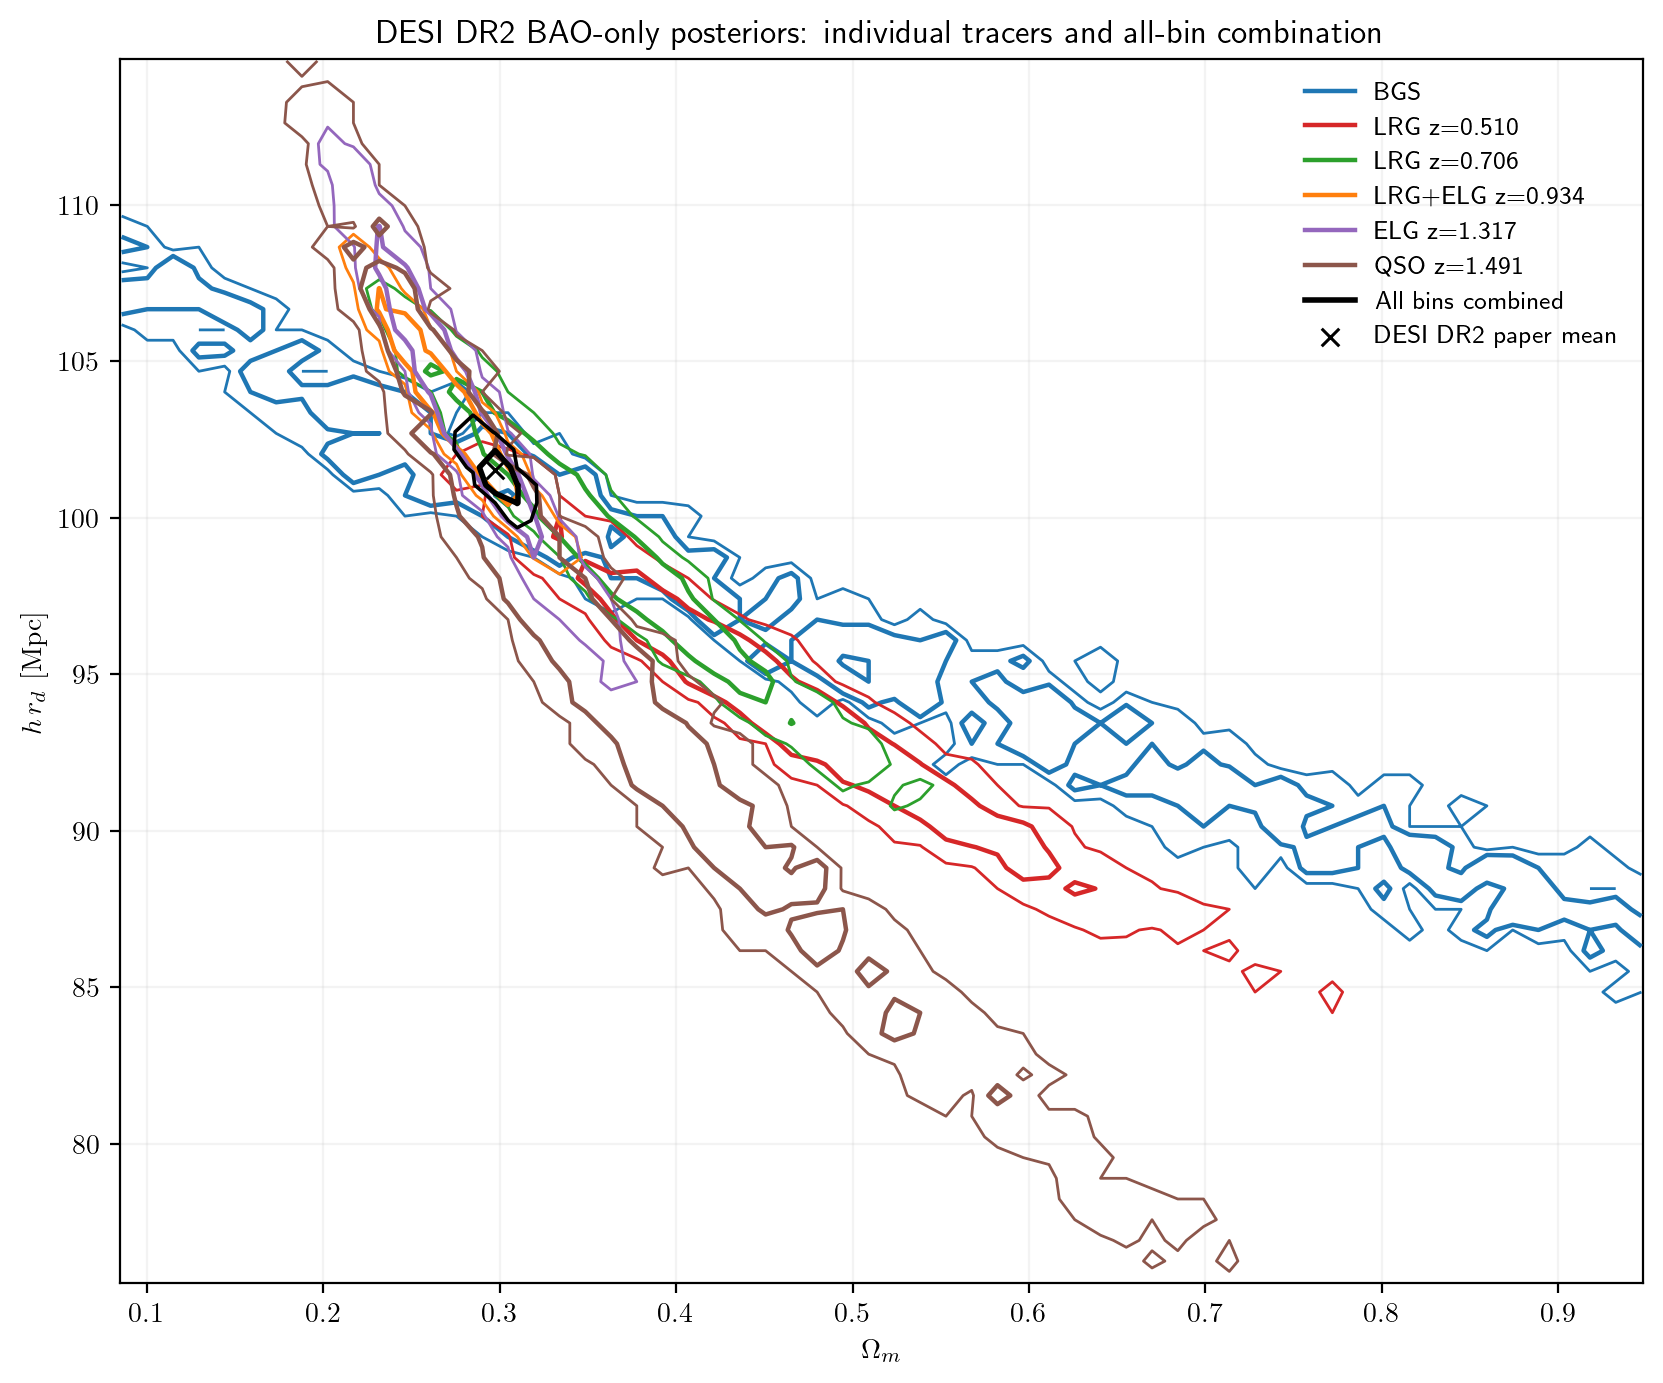

In [14]:
from scipy.ndimage import gaussian_filter

def density_levels_from_hist(hist, credible_levels=(0.68, 0.95)):
    flat = hist.ravel()
    flat = flat[np.isfinite(flat)]
    if flat.size == 0 or np.all(flat <= 0.0):
        return []
    order = np.argsort(flat)[::-1]
    sorted_hist = flat[order]
    cdf = np.cumsum(sorted_hist)
    cdf /= cdf[-1]
    levels = []
    for cl in credible_levels:
        idx = np.searchsorted(cdf, cl, side='left')
        idx = min(idx, sorted_hist.size - 1)
        levels.append(sorted_hist[idx])
    return sorted(set(levels))

def plot_smoothed_contours(
    ax,
    samples,
    color,
    bins,
    x_range,
    y_range,
    *,
    label=None,
    smoothing_sigma=1.0,
    fill_alphas=(0.10, 0.22),
    lw=(1.0, 1.6),
    zorder=3,
):
    hist, xedges, yedges = np.histogram2d(
        samples[:, 1], samples[:, 0], bins=bins, range=[x_range, y_range]
    )
    hist = gaussian_filter(hist, sigma=smoothing_sigma)
    levels = density_levels_from_hist(hist)
    if levels:
        xcenters = 0.5 * (xedges[:-1] + xedges[1:])
        ycenters = 0.5 * (yedges[:-1] + yedges[1:])
        level_lo, level_hi = levels[0], levels[-1]
        ax.contourf(
            xcenters,
            ycenters,
            hist.T,
            levels=[level_lo, hist.max()],
            colors=[color],
            alpha=fill_alphas[0],
            zorder=zorder,
        )
        ax.contourf(
            xcenters,
            ycenters,
            hist.T,
            levels=[level_hi, hist.max()],
            colors=[color],
            alpha=fill_alphas[1],
            zorder=zorder + 0.1,
        )
        ax.contour(
            xcenters,
            ycenters,
            hist.T,
            levels=levels,
            colors=[color],
            linewidths=lw[:len(levels)],
            zorder=zorder + 0.2,
        )
    if label is not None:
        ax.plot([], [], color=color, lw=lw[-1], label=label)

def run_bao_only_dataset_posterior(bao_data, seed):
    theory_fn = jax.jit(make_bao_only_paper_theory_fn(bao_data))
    cov_inv_local = inv(bao_data.cov)
    _, to_physical_local = make_transform(BAO_ONLY_CENTER, BAO_ONLY_SCALE)
    log_post_local = make_log_posterior(
        theory_fn=theory_fn,
        data=bao_data.data_vector,
        cov_inv=cov_inv_local,
        log_prior_fn=bao_only_log_prior,
        to_physical=to_physical_local,
    )
    samples_w_local, diagnostics_local = run_nuts(
        jax.random.key(seed),
        log_post_local,
        initial_position=jnp.zeros(2),
        num_warmup=TRACER_NUM_WARMUP,
        num_samples=TRACER_NUM_SAMPLES,
        num_chains=TRACER_NUM_CHAINS,
        max_tree_depth=TRACER_MAX_TREE_DEPTH,
        scan_chunk_size=TRACER_SCAN_CHUNK,
        parallel_chains=True,
    )
    samples_local = np.asarray(
        samples_to_physical(samples_w_local, to_physical_local)
    ).reshape(-1, 2)
    divergent = np.asarray(diagnostics_local['is_divergent']).reshape(-1).astype(bool)
    valid = ~divergent
    return samples_local[valid] if np.any(valid) else samples_local

bao_all_only = load_desi_dr2('all', data_dir=bao_data_dir)
combined_bao_only_samples = run_bao_only_dataset_posterior(bao_all_only, seed=500)

all_plot_samples = np.vstack(
    [combined_bao_only_samples] + [galaxy_posteriors[name]['samples'] for name, _ in GALAXY_TRACERS]
)
x_lo, x_hi = np.percentile(all_plot_samples[:, 1], [0.5, 99.5])
y_lo, y_hi = np.percentile(all_plot_samples[:, 0], [0.5, 99.5])
x_pad = 0.08 * (x_hi - x_lo)
y_pad = 0.08 * (y_hi - y_lo)
x_range = (x_lo - x_pad, x_hi + x_pad)
y_range = (y_lo - y_pad, y_hi + y_pad)

paper_bao_only_mean = np.array([0.2975, 101.54])
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']

fig, ax = plt.subplots(figsize=(8.2, 6.8), constrained_layout=True)
for color, (name, label) in zip(colors, GALAXY_TRACERS):
    plot_smoothed_contours(
        ax,
        galaxy_posteriors[name]['samples'],
        color=color,
        bins=70,
        x_range=x_range,
        y_range=y_range,
        label=label,
        smoothing_sigma=1.0,
        fill_alphas=(0.08, 0.18),
        lw=(1.0, 1.5),
        zorder=3,
    )

plot_smoothed_contours(
    ax,
    combined_bao_only_samples,
    color='black',
    bins=80,
    x_range=x_range,
    y_range=y_range,
    label='All bins combined',
    smoothing_sigma=1.1,
    fill_alphas=(0.12, 0.28),
    lw=(1.2, 1.9),
    zorder=5,
)

ax.scatter(
    paper_bao_only_mean[1], paper_bao_only_mean[0],
    marker='x', s=40, color='black', linewidths=1.1,
    zorder=6, label='DESI DR2 paper mean',
)
ax.set_xlabel(r'$H_0\,r_d\ [{\mathrm{km\,s^{-1}}}]$')
ax.set_ylabel(r'$\Omega_m$')
ax.grid(alpha=0.15)
ax.legend(fontsize=9, frameon=False, loc='upper right')
ax.set_title(r'DESI DR2 BAO-only posteriors: individual tracers and all-bin combination')
